### Complete all codes, and finish training and inference

##### Task1

In [1]:
# =======================1-1-2-pip: Enter the command to view the third-party libraries installed in the current environment.==================
!pip list

Package                 Version
----------------------- --------------
absl-py                 2.3.1
arrow                   1.4.0
attrs                   23.2.0
backcall                0.2.0
binaryornot             0.4.4
certifi                 2022.9.24
cffi                    2.0.0
chardet                 5.2.0
charset-normalizer      3.4.4
click                   8.1.8
comm                    0.1.4
configparser            6.0.0
contourpy               1.3.0
cookiecutter            2.6.0
cryptography            3.4.7
cycler                  0.11.0
debugpy                 1.6.3
decorator               5.1.1
defusedxml              0.8.0rc2
entrypoints             0.4
esdk-obs-python         3.23.12
filelock                3.12.2
fonttools               4.38.0
greenlet                3.2.4
grpcio                  1.76.0
huaweicloudsdkcore      3.1.94
huggingface-hub         0.0.8
idna                    3.11
ijson                   3.4.0.post0
importlib-metadata      6.7.0
importlib-r

In [2]:
# ==========================1-2-1-unzip: Download the file archive and extract it. ==============
# !wget https://ictdata.obs.ap-southeast-3.myhuaweicloud.com/ai/BERT-Classification_EN.zip
# !unzip -o BERT-Classification_EN.zip
# !ls -la

In [3]:
# ==========================1-2-2-env-1: Install transformers ==============


In [4]:
# ==========================1-2-2-env-2: Install transformer ==============
!pip install transformers==4.6.1

Looking in indexes: http://192.168.0.94:8888/repository/pypi/simple
You should consider upgrading via the '/home/ma-user/anaconda3/envs/python-3.7.10/bin/python3.7 -m pip install --upgrade pip' command.


In [5]:
!pip install torchtext==0.11.0

Looking in indexes: http://192.168.0.94:8888/repository/pypi/simple
You should consider upgrading via the '/home/ma-user/anaconda3/envs/python-3.7.10/bin/python3.7 -m pip install --upgrade pip' command.


In [6]:
# ==========================1-2-2-env-3: Install seaborn ==============
!pip install seaborn


Looking in indexes: http://192.168.0.94:8888/repository/pypi/simple
You should consider upgrading via the '/home/ma-user/anaconda3/envs/python-3.7.10/bin/python3.7 -m pip install --upgrade pip' command.


In [7]:
# ==========================1-2-2-env-4: upgrade jupyter ipywidgets==============
!pip install --upgrade ipywidgets

Looking in indexes: http://192.168.0.94:8888/repository/pypi/simple
You should consider upgrading via the '/home/ma-user/anaconda3/envs/python-3.7.10/bin/python3.7 -m pip install --upgrade pip' command.


In [8]:
# ==========================1-2-2-env-5: Check the successfully installed third-party libraries==============
!pip show transformers torchtext seaborn ipywidgets

Name: transformers
Version: 4.6.1
Summary: State-of-the-art Natural Language Processing for TensorFlow 2.0 and PyTorch
Home-page: https://github.com/huggingface/transformers
Author: Thomas Wolf, Lysandre Debut, Victor Sanh, Julien Chaumond, Sam Shleifer, Patrick von Platen, Sylvain Gugger, Suraj Patil, Stas Bekman, Google AI Language Team Authors, Open AI team Authors, Facebook AI Authors, Carnegie Mellon University Authors
Author-email: thomas@huggingface.co
License: Apache
Location: /home/ma-user/anaconda3/envs/python-3.7.10/lib/python3.7/site-packages
Requires: requests, filelock, tokenizers, regex, numpy, huggingface-hub, importlib-metadata, tqdm, packaging, sacremoses
Required-by: 
---
Name: torchtext
Version: 0.11.0
Summary: Text utilities and datasets for PyTorch
Home-page: https://github.com/pytorch/text
Author: PyTorch core devs and James Bradbury
Author-email: jekbradbury@gmail.com
License: BSD
Location: /home/ma-user/anaconda3/envs/python-3.7.10/lib/python3.7/site-packages
R

In [9]:
import ipywidgets
print(ipywidgets.__version__)  # Should show 7.6.0 or higher

8.1.8


In [12]:
!pip install scikit-learn

Looking in indexes: http://192.168.0.94:8888/repository/pypi/simple
     |████████████████████████████████| 24.8 MB 53.7 MB/s eta 0:00:01
You should consider upgrading via the '/home/ma-user/anaconda3/envs/python-3.7.10/bin/python3.7 -m pip install --upgrade pip' command.


##### Task2

In [18]:
import sys

sys.path = [p for p in sys.path if 'modelarts-sdk' not in p]

import importlib
import importlib.util
modelarts_paths = [p for p in sys.path if 'modelarts' in p.lower()]

from tqdm.notebook import tqdm
tqdm.pandas()

import pickle
import time
import string
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchtext.legacy import data
import torch.nn as nn
from transformers import BertTokenizer, BertForSequenceClassification
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

RANDOM_STATE = 42
PATH = 'BERT-Classification/data'

Device: cpu


In [20]:
!find . -name "*.csv" 2>/dev/null

./BERT-Classification/data/news_dataset.csv


# Loading and processing dataset

### Load raw dataset

In [22]:
# ==========================2-2-1-load: Load data ==============
raw_df = pd.read_csv('./BERT-Classification/data/news_dataset.csv')
# ==================================================================

In [25]:
# ==========================2-2-2-print: Print the headers of the CSV file==============
print(raw_df.dtypes)
# ===========================================================================

Title       object
Body        object
Summary     object
Category    object
dtype: object


In [26]:
# ==========================2-2-3-print: Check the number of rows and columns of the data==============
print(raw_df.shape)
# ===========================================================================

(2225, 4)


In [27]:
# ==========================2-2-4-print: Print the first 3 rows of the training data==============
print(raw_df.head(3))
# ===========================================================================

                               Title  \
0    Fed chief warning on US deficit   
1     Saudi ministry to employ women   
2  Deutsche Telekom sees mobile gain   

                                                Body  \
0  Federal Reserve chairman Alan Greenspan has wa...   
1  Women will be employed in Saudi Arabia's forei...   
2  German telecoms firm Deutsche Telekom saw stro...   

                                             Summary  Category  
0  Federal Reserve chairman Alan Greenspan has wa...  business  
1  Women will be employed in Saudi Arabia's forei...  business  
2  A year ago, debt was more than 11bn euros high...  business  


In [29]:
# =====================2-3-1-print: Print the categories contained in the Category column====================
column_name = 'Category'

unique_categories = raw_df[column_name].unique()
print("five categories:", unique_categories)
# ===========================================================================

five categories: ['business' 'entertainment' 'politics' 'sport' 'tech']


### Pre-process text

In [31]:
# ==========================2-3-2-count: Count the data volume for each field.==============
counts = raw_df[column_name].value_counts()
print("\nrows of per category:")
print(counts)
# ===========================================================================


rows of per category:
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: Category, dtype: int64


In [32]:
# ========================2-3-3-save：Screenshot of code: delete data and save new CSV file================
# 1. Calculate the number of the smallest category
min_count = raw_df[column_name].value_counts().min()
print(min_count)
# 2. Group by category and randomly sample min_count rows for each group
raw_df = raw_df.groupby(column_name, group_keys=False).apply(lambda x: x.sample(n=min_count, random_state=42))
# 3. Reset index
raw_df = raw_df.reset_index(drop=True)
# 4. Verify the result
print("\nAfter downsampling:")
print(raw_df[column_name].value_counts())
# save downsampled CSV
raw_df.to_csv(PATH + '/downsampled.csv', index=False)
print("Saved downsampled.csv")

# ===========================================================================

386

After downsampling:
business         386
entertainment    386
politics         386
sport            386
tech             386
Name: Category, dtype: int64
Saved downsampled.csv


In [33]:
# =========2-3-4-preprocess: Define the text truncation length and implement a function for text truncation==============
MAX_SEQ_LEN = 150

def preprocess_text(text):
    # a) Split text into list of words separated by spaces
    words = str(text).split(' ')
    # b) Take first 150 words and recombine
    words = words[:MAX_SEQ_LEN]
    text = ' '.join(words)
    # c) Convert to lowercase
    text = text.lower()
    # d) Return processed text
    return text
# ===========================================================================

In [34]:
raw_df['Title'] = raw_df['Title'].apply(lambda x: preprocess_text(x))
raw_df['Body'] = raw_df['Body'].apply(lambda x: preprocess_text(x))
raw_df['Summary'] = raw_df['Summary'].apply(lambda x: preprocess_text(x))

### Prepare columns for concatenated texts and integer labels

In [35]:
# =================================2-4-1-newDF============================
labels = list(raw_df['Category'].unique())
df = pd.DataFrame(columns=['label', 'titlebody'])
df['label'] = raw_df['Category'].apply(lambda x: labels.index(x))
df['titlebody'] = raw_df['Title'] + ". " + raw_df['Body']
df
# ======================================================================================

,label,titlebody
0,0,ba to suspend two saudi services. british airw...
1,0,minister hits out at yukos sale. russia's rena...
2,0,tsunami slows sri lanka's growth. sri lanka's ...
3,0,news corp makes $5.4bn fox offer. news corpora...
4,0,lloyd's of london head chides fsa. the head of...
...,...,...
1925,4,dublin hi-tech labs to shut down. dublin's hi-...
1926,4,warnings on woeful wi-fi security. companies a...
1927,4,"when technology gets personal. in 2020, whippi..."
1928,4,web radio takes spanish rap global. spin the r...


In [36]:
# =================================2-4-2-printDF==========================
print(df)
# ======================================================================================

      label                                          titlebody
0         0  ba to suspend two saudi services. british airw...
1         0  minister hits out at yukos sale. russia's rena...
2         0  tsunami slows sri lanka's growth. sri lanka's ...
3         0  news corp makes $5.4bn fox offer. news corpora...
4         0  lloyd's of london head chides fsa. the head of...
...     ...                                                ...
1925      4  dublin hi-tech labs to shut down. dublin's hi-...
1926      4  warnings on woeful wi-fi security. companies a...
1927      4  when technology gets personal. in 2020, whippi...
1928      4  web radio takes spanish rap global. spin the r...
1929      4  'brainwave' cap controls computer. a team of u...

[1930 rows x 2 columns]


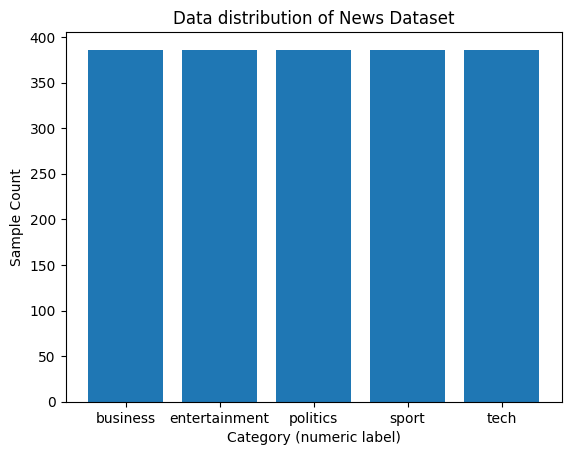

In [37]:
# ===============================2-5-1-virtualization========================
category_counts = df.groupby('label').size()
category, values = category_counts.index.tolist(), category_counts.values.tolist()
plt.bar(category, values)
plt.title("Data distribution of News Dataset")
plt.xlabel('Category (numeric label)')
plt.ylabel('Sample Count')
plt.xticks(np.arange(5), labels)
plt.show()
# =========================================================================================

### Split dataset into train, valid, test

In [38]:
# =============================Subtask 6===================================

#  1. 2-6-1-LabelDict
LABEL_MAPPING = {
    0: labels[0],
    1: labels[1],
    2: labels[2],
    3: labels[3],
    4: labels[4],
}
print("Label mapping:", LABEL_MAPPING)

# 2. 2-6-2-set
TRAIN_RATIO = 0.8
VALID_TEST_RATIO = 0.5

# 3. 2-6-3-split
def split_category_data(df_category, train_ratio=TRAIN_RATIO, random_state=RANDOM_STATE):
    """
    Split the DataFrame of a single category into train-valid-test sets with a ratio of 8:1:1
    :param df_category: Original DataFrame of a single category
    :param train_ratio: Proportion of the training set (default 0.8)
    :param random_state: Random seed (ensures consistent split results)
    :return: (train_df, valid_df, test_df)
    """
    # Step 1: Split the data into the training set (80%) and the remaining part (20%)
    df_train, df_rem = train_test_split(
        df_category,
        train_size=train_ratio,
        random_state=random_state
    )
    # Step 2: Split the remaining 20% into the validation set (10%) and the test set (10%)
    df_valid, df_test = train_test_split(
        df_rem,
        test_size=VALID_TEST_RATIO,
        random_state=random_state
    )
    return df_train, df_valid, df_test
# =====================================================================


Label mapping: {0: 'business', 1: 'entertainment', 2: 'politics', 3: 'sport', 4: 'tech'}


In [39]:
# ===========================Subtask7=============================
# 1. Split all categories by label and store them in a dictionary
category_dfs = {name: df[df['label'] == label] for label, name in LABEL_MAPPING.items()}

# 2. Iterate through each category, perform an 8:1:1 split, and store the results in a dictionary
split_results = {}
for cat_name, cat_df in category_dfs.items():
    train_df, valid_df, test_df = split_category_data(
        cat_df,
        train_ratio=TRAIN_RATIO,
        random_state=RANDOM_STATE
    )
    split_results[cat_name] = (train_df, valid_df, test_df)

# 3. Combine all splits
train_data = pd.concat([v[0] for v in split_results.values()]).reset_index(drop=True)
valid_data = pd.concat([v[1] for v in split_results.values()]).reset_index(drop=True)
test_data  = pd.concat([v[2] for v in split_results.values()]).reset_index(drop=True)


In [40]:
# Save to file
train_data.to_csv(PATH + '/train.csv', index=False)
valid_data.to_csv(PATH + '/valid.csv', index=False)
test_data.to_csv(PATH + '/test.csv', index=False)


In [41]:
 # ===============================2-7-2-train ======================
 # ===============================2-7-2-train ======================
print(train_data)
print('Train size:', len(train_data))


      label                                          titlebody
0         0  barclays profits hit record level. barclays, t...
1         0  soros group warns of kazakh close. the open so...
2         0  worldcom trial starts in new york. the trial o...
3         0  french suitor holds lse meeting. european stoc...
4         0  indy buys into india paper. irish publishing g...
...     ...                                                ...
1535      4  consumers 'snub portable video'. consumers wan...
1536      4  virus poses as christmas e-mail. security firm...
1537      4  broadband in the uk growing fast. high-speed n...
1538      4  half of uk's mobiles 'go online'. multimedia m...
1539      4  eu software patent law faces axe. the european...

[1540 rows x 2 columns]
Train size: 1540


In [42]:
 # ===============================2-7-2-valid ======================
 # ===============================2-7-2-valid ======================
print(valid_data)
print('Valid size:', len(valid_data))


     label                                          titlebody
0        0  metlife buys up citigroup insurer. us banking ...
1        0  'strong dollar' call halts slide. the us dolla...
2        0  indonesians face fuel price rise. indonesia's ...
3        0  bmw reveals new models pipeline. bmw is prepar...
4        0  britannia members' â£42m windfall. more than 8...
..     ...                                                ...
190      4  online commons to spark debate. online communi...
191      4  cable offers video-on-demand. cable firms ntl ...
192      4  broadband set to revolutionise tv. bt is start...
193      4  microsoft gets the blogging bug. software gian...
194      4  confusion over high-definition tv. now that a ...

[195 rows x 2 columns]
Valid size: 195


In [43]:
 # ===============================2-7-2-test ======================
 # ===============================2-7-2-test ======================
print(test_data)
print('Test size:', len(test_data))


     label                                          titlebody
0        0  european losses hit gm's profits. general moto...
1        0  japan bank shares up on link talk. shares of s...
2        0  eu-us seeking deal on air dispute. the eu and ...
3        0  oil rebounds from weather effect. oil prices r...
4        0  s korean credit card firm rescued. south korea...
..     ...                                                ...
190      4  ibm puts cash behind linux push. ibm is spendi...
191      4  cabs collect mountain of mobiles. gadgets are ...
192      4  cheaper chip for mobiles. a mobile phone chip ...
193      4  ban hits half-life 2 pirates hard. about 20,00...
194      4  iran jails blogger for 14 years. an iranian we...

[195 rows x 2 columns]
Test size: 195


# Fine-tuning a pre-trained Bert model

Uses “bert-base-uncased” version of BERT, which is pre-trained on lower-cased English text

(with 12-layer, 768-hidden, 12-heads, 110M parameters)

For the purposes of fine-tuning, recommend choosing from the following values 

*   **Batch size:** 8, 16
*   **Learning rate (Adam):** 5e-5, 3e-5, 2e-5
*   **Number of epochs:** 2, 3, 4

In [44]:
bert_path = "./bert-base-uncased"
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
tokenizer = BertTokenizer.from_pretrained(bert_path)
# Model parameters
BATCH_SIZE = 8
MAX_SEQ_LEN = 200
PAD_INDEX = tokenizer.convert_tokens_to_ids(tokenizer.pad_token)
UNK_INDEX = tokenizer.convert_tokens_to_ids(tokenizer.unk_token)

# Fields
label_field = data.Field(sequential=False, use_vocab=False, batch_first=True, dtype=torch.float)
text_field = data.Field(use_vocab=False, tokenize=tokenizer.encode, lower=False, include_lengths=False, batch_first=True, fix_length=MAX_SEQ_LEN, pad_token=PAD_INDEX, unk_token=UNK_INDEX)
fields = [('label', label_field), ('titlebody', text_field)]

# TabularDataset
train, valid, test = data.TabularDataset.splits(path=PATH, train='train.csv', validation='valid.csv', test='test.csv', format='CSV', fields=fields, skip_header=True)

# Iterators
train_iter = data.BucketIterator(train, batch_size=BATCH_SIZE, sort_key=lambda x: len(x.titlebody), device=device, train=True, sort=True, sort_within_batch=True)
valid_iter = data.BucketIterator(valid, batch_size=BATCH_SIZE, sort_key=lambda x: len(x.titlebody), device=device, train=True, sort=True, sort_within_batch=True)
test_iter = data.Iterator(test, batch_size=BATCH_SIZE, device=device, train=False, shuffle=False, sort=False)


Downloading: 0.00B [00:00, ?B/s]

Downloading:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

Downloading: 0.00B [00:00, ?B/s]

In [45]:
# ====================================2-8-1-Model ===========================================================
class BertModel(nn.Module):
    def __init__(self):
        super(BertModel, self).__init__()
        self.encoder = BertForSequenceClassification.from_pretrained(bert_path, num_labels=5)

    def forward(self, text, label):
        loss, logits = self.encoder(text, labels=label)[:2]
        return loss, logits
# =========================================================================================================================


### Save data

In [49]:
def save_model(path, model, valid_loss):
    state_dict = {'model_state_dict': model.state_dict(),
                  'valid_loss': valid_loss}
    torch.save(state_dict, path)



def save_metrics(path, train_loss_list, valid_loss_list, global_steps_list):
    state_dict = {
        'train_loss_list': train_loss_list,
        'valid_loss_list': valid_loss_list,
        'global_steps_list': global_steps_list
    }
    torch.save(state_dict, path)
# ===================================================================================

In [50]:
# ========================2-10-1-load_metrics=======================
def load_metrics(path):
    state_dict = torch.load(path, map_location=device)
    return state_dict['train_loss_list'], state_dict['valid_loss_list'], state_dict['global_steps_list']
# ============================================================================


In [51]:
# ========================2-11-1-print_model_params=======================
def print_model_params(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    model_size_mb = round(total_params * 4 / (1024 ** 2), 2)  # FP32 = 4 bytes per param

    print(f"total_params: {total_params:,}")
    print(f"trainable_params: {trainable_params:,}")
    print(f"Model Size: {model_size_mb} MB (FP32)")

    return total_params, trainable_params
# ============================================================================


In [52]:
# ========================2-12-1-model_info=======================
model = BertModel().to(device)
print_model_params(model)
# ==========================================================================


Downloading:   0%|          | 0.00/570 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at ./bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint 

total_params: 109,486,085
trainable_params: 109,486,085
Model Size: 417.66 MB (FP32)


(109486085, 109486085)

In [53]:
# ===================2-13-1-train_param: To be modified.======================
def train(model, optimizer, train_set=train_iter, valid_set=valid_iter,
          num_epochs=5, eval_every=len(train_iter) // 3,
          file_path=PATH, best_valid_loss=float("Inf")):
# ======================================================================

    running_loss = 0.0
    valid_running_loss = 0.0
    global_step = 0
    train_loss_list = []
    valid_loss_list = []
    global_steps_list = []

    inference_time = 0.0
    inference_count = 0

    # =========================2-14-1-train: Training mode ===========================
    model.train()
    # ===================================================================================

    for epoch in tqdm(range(num_epochs)):
        print('======= Epoch [{}/{}] ======='.format(epoch+1, num_epochs))

        for (labels, titlebody), _ in tqdm(train_set):

            labels = labels.type(torch.LongTensor)
            labels = labels.to(device)
            titlebody = titlebody.type(torch.LongTensor)
            titlebody = titlebody.to(device)
            start_time = time.time()
            # =========================2-14-1-train: Complete the code for calculating the loss ===========================
            loss, _ = model(titlebody, labels)
            # ============================================================================
            time_taken = time.time() - start_time
            inference_time += time_taken
            inference_count += 1
            # =========================2-15-1-BP===========================
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            # ============================================================================

            running_loss += loss.item()
            global_step += 1

            # ============================ 2-16-1-bool ====================================
            if global_step % eval_every == 0:          # Validate 3 times per epoch
                model.eval()                           # Set eval mode
                with torch.no_grad():                  # Disable gradient computation

                    # Validation loop
                    for (labels, titlebody), _ in valid_set:   # Iterate over valid set
                        labels = labels.type(torch.LongTensor)
                        labels = labels.to(device)
                        titlebody = titlebody.type(torch.LongTensor)
                        titlebody = titlebody.to(device)
                        loss, _ = model(titlebody, labels)    # Forward pass

                        valid_running_loss += loss.item()      # Accumulate validation loss

                # Compute metrics
                average_train_loss = running_loss / eval_every
                average_valid_loss = valid_running_loss / len(valid_set)
                train_loss_list.append(average_train_loss)
                valid_loss_list.append(average_valid_loss)
                global_steps_list.append(global_step)

                # Reset running values
                running_loss = 0.0
                valid_running_loss = 0.0
                model.train()

                # Log progress
                print('Epoch [{}/{}], Step [{}/{}], Train Loss: {:.4f}, Valid Loss: {:.4f}'
                    .format(epoch+1, num_epochs, global_step, num_epochs*len(train_set),
                            average_train_loss, average_valid_loss))

                # Save Model
                if best_valid_loss > average_valid_loss:
                    best_valid_loss = average_valid_loss
                    save_model(file_path + '/model.pt', model, best_valid_loss)
                    save_metrics(file_path + '/metrics.pt', train_loss_list, valid_loss_list, global_steps_list)

    save_metrics(file_path + '/metrics.pt', train_loss_list, valid_loss_list, global_steps_list)
    inference_time = inference_time / inference_count
    print("Inference Time: %.4f s" % inference_time)
    print('Training complete!')


In [54]:
# =========================17 Model Init and Training Start ===========================
model = BertModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-5)
train(model, optimizer)
# ============================================================================


Some weights of the model checkpoint at ./bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint 

  0%|          | 0/5 [00:00<?, ?it/s]

======= Epoch [1/5] =======


  0%|          | 0/193 [00:00<?, ?it/s]

Epoch [1/5], Step [64/965], Train Loss: 1.2254, Valid Loss: 0.8772
Epoch [1/5], Step [128/965], Train Loss: 0.4297, Valid Loss: 0.1968
Epoch [1/5], Step [192/965], Train Loss: 0.1728, Valid Loss: 0.0795
======= Epoch [2/5] =======


...

Epoch [3/5], Step [448/965], Train Loss: 0.0577, Valid Loss: 0.1515
Epoch [3/5], Step [512/965], Train Loss: 0.0447, Valid Loss: 0.0303
Epoch [3/5], Step [576/965], Train Loss: 0.0115, Valid Loss: 0.0187
======= Epoch [4/5] =======


  0%|          | 0/193 [00:00<?, ?it/s]

Epoch [4/5], Step [640/965], Train Loss: 0.0622, Valid Loss: 0.0797
Epoch [4/5], Step [704/965], Train Loss: 0.0201, Valid Loss: 0.0258
Epoch [4/5], Step [768/965], Train Loss: 0.0360, Valid Loss: 0.0679
======= Epoch [5/5] =======


  0%|          | 0/193 [00:00<?, ?it/s]

Epoch [5/5], Step [832/965], Train Loss: 0.0727, Valid Loss: 0.1359
Epoch [5/5], Step [896/965], Train Loss: 0.0234, Valid Loss: 0.0350
Epoch [5/5], Step [960/965], Train Loss: 0.0352, Valid Loss: 0.0583
Inference Time: 0.4842 s
Training complete!


### Plot Training and Validation Loss

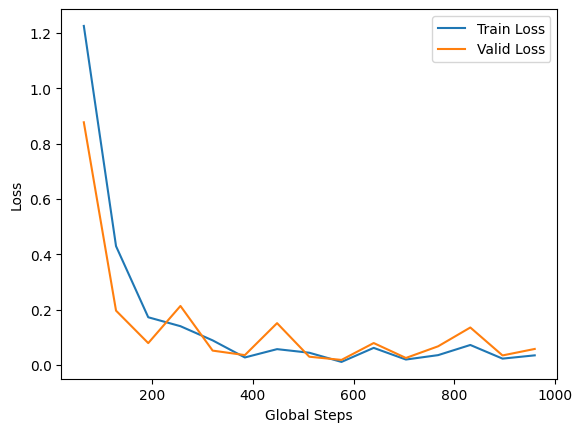

In [55]:
# =========================2-18-1-Virtualization_train ====================
train_loss_list, valid_loss_list, global_steps_list = load_metrics(PATH + '/metrics.pt')
# 1: Plot training loss curve
plt.plot(global_steps_list, train_loss_list, label='Train Loss')

# 2: Plot validation loss curve
plt.plot(global_steps_list, valid_loss_list, label='Valid Loss')

plt.xlabel('Global Steps')
plt.ylabel('Loss')
plt.legend()
plt.show()
# ============================================================================


### Evaluation

In [56]:
# =========================3-1-1-load_model====================
def load_model(path, model):
    state_dict = torch.load(path, map_location=device)
    model.load_state_dict(state_dict['model_state_dict'])
    return state_dict['valid_loss']
# ======================================================================


In [57]:
def evaluate(model, test_set=test_iter):
    y_pred = []
    y_true = []
    # =========================3-2-1-mode ====================
    model.eval()
    # ======================================================================
    with torch.no_grad():

        for (labels, titlebody), _ in tqdm(test_set):
            labels = labels.type(torch.LongTensor)
            labels = labels.to(device)
            titlebody = titlebody.type(torch.LongTensor)
            titlebody = titlebody.to(device)
            output = model(titlebody, labels)
            _, output = output
            y_pred.extend(torch.argmax(output, 1).tolist())
            y_true.extend(labels.tolist())

    print('Classification Report:')
    # =========================3-3-1-report ====================
    report = classification_report(y_true, y_pred, target_names=['business', 'entertainment', 'politics', 'sport', 'tech'])
    print(report)
    # =========================================================================

    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])
    ax = plt.subplot()

    # =========================3-4-1-CM =========================
    sns.heatmap(cm, annot=True, ax=ax, cmap='Reds', fmt='g')
    # =========================================================================

    ax.set_title('Confusion Matrix')
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')
    ax.xaxis.set_ticklabels(['business', 'entertainment', 'politics', 'sport', 'tech'])
    ax.yaxis.set_ticklabels(['business', 'entertainment', 'politics', 'sport', 'tech'])


Some weights of the model checkpoint at ./bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint 

  0%|          | 0/25 [00:00<?, ?it/s]

Classification Report:
               precision    recall  f1-score   support

     business       1.00      0.95      0.97        39
entertainment       0.97      0.97      0.97        39
     politics       0.95      0.97      0.96        39
        sport       1.00      1.00      1.00        39
         tech       0.95      0.97      0.96        39

     accuracy                           0.97       195
    macro avg       0.97      0.97      0.97       195
 weighted avg       0.97      0.97      0.97       195



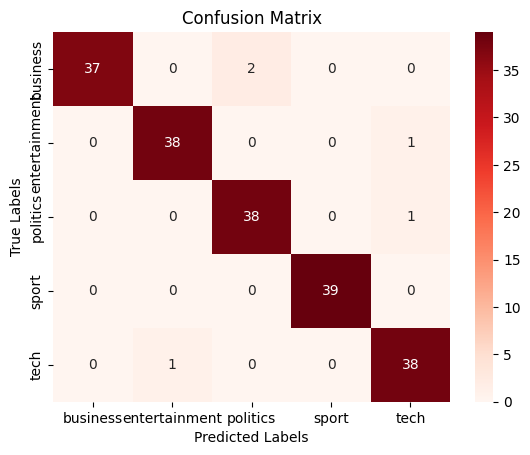

In [58]:
bert_model = BertModel().to(device)
load_model(PATH + '/model.pt', bert_model)
evaluate(bert_model, test_iter)


In [74]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the pre-trained BERT tokenizer and model
bert_path = "./bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(bert_path)
model = BertForSequenceClassification.from_pretrained(bert_path, num_labels=5).to(device)

# Load the model weights
model_path = "./BERT-Classification/data/model.pt"
checkpoint = torch.load(model_path, map_location=device)


state_dict = checkpoint['model_state_dict']
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith("encoder."):
        new_key = key[len("encoder."):]  # Remove "encoder." prefix
    else:
        new_key = key
    new_state_dict[new_key] = value

# Load the remapped weights
model.load_state_dict(new_state_dict, strict=True)
model.eval()
print(" Model loaded successfully!")

# Define the category labels
labels = ['business', 'entertainment', 'politics', 'sport', 'tech']

# Define the preprocessing function
def preprocess_text(text, max_seq_len=200):
    inputs = tokenizer.encode_plus(
        text,
        None,
        add_special_tokens=True,
        max_length=max_seq_len,
        padding='max_length',
        return_token_type_ids=True,
        truncation=True
    )
    ids = inputs['input_ids']
    mask = inputs['attention_mask']
    return {
        'ids': torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device),
        'mask': torch.tensor(mask, dtype=torch.long).unsqueeze(0).to(device)
    }

# =========================4-1-1-test_single =========================
def test_single_example(text):
    inputs = preprocess_text(text)
    ids = inputs['ids']
    mask = inputs['mask']

    with torch.no_grad():
        outputs = model(input_ids=ids, attention_mask=mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).item()

    predicted_label = labels[preds]
    print(f"Input Text: {text}")
    print(f"Predicted Label: {predicted_label}")

# =========================================================================
# Test example
test_text = "The government announced new measures to boost economic growth."
test_single_example(test_text)

Some weights of the model checkpoint at ./bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint 

 Model loaded successfully!
Input Text: The government announced new measures to boost economic growth.
Predicted Label: business


In [72]:
# =========================4-2-1-test_batch =========================
def test_batch_examples(texts):
    print(f"\nBatch inference on {len(texts)} examples:")
    for text in texts:
        test_single_example(text)
        print()
# =================================================================================


In [73]:
# Test examples
test_texts = [
    "The government announced new measures to boost economic growth and create jobs in various sectors.",
    "The football team won the championship after an exciting final match against their rivals.",
    "New smartphone with advanced features and improved camera technology was launched today.",
    "The movie starring famous actors received positive reviews from critics and audiences alike.",
    "Political leaders discussed international relations and trade agreements at the summit.",
    "Stock market showed significant gains as investors responded to positive economic indicators.",
    "Basketball team secured their place in the playoffs with a decisive victory last night.",
    "Tech company unveiled its latest innovation in artificial intelligence and machine learning.",
    "Celebrities attended the red carpet event for the annual film awards ceremony.",
    "Economic policies aimed at reducing inflation were implemented by the central bank."
]

test_batch_examples(test_texts)



Batch inference on 10 examples:
Input Text: The government announced new measures to boost economic growth and create jobs in various sectors.
Predicted Label: business

Input Text: The football team won the championship after an exciting final match against their rivals.
Predicted Label: sport

Input Text: New smartphone with advanced features and improved camera technology was launched today.
Predicted Label: tech

Input Text: The movie starring famous actors received positive reviews from critics and audiences alike.
Predicted Label: entertainment

Input Text: Political leaders discussed international relations and trade agreements at the summit.
Predicted Label: politics

Input Text: Stock market showed significant gains as investors responded to positive economic indicators.
Predicted Label: business

Input Text: Basketball team secured their place in the playoffs with a decisive victory last night.
Predicted Label: sport

Input Text: Tech company unveiled its latest innovation i

### Freeze

In [64]:
# =========================5-1-1-freeze ========================
import torch
import torch.nn as nn
from transformers import BertForSequenceClassification

class BertModelFreeze(nn.Module):
    def __init__(self, freeze_strategy="full_bert", freeze_encoder_layers=6):
        """
        Args:
            freeze_strategy:
                - 'full_bert': Freeze the entire BERT backbone (only train the classification head)
                - 'partial_bert': Freeze the Embedding layer + the first N Encoder layers
                - 'only_embedding': Freeze only the Embedding layer
            freeze_encoder_layers: Only effective for partial_bert; specifies freezing the first N Encoder layers.
        """
        super(BertModelFreeze, self).__init__()

        # 1. Load the local BERT model
        self.encoder = BertForSequenceClassification.from_pretrained(
            "./bert-base-uncased",
            num_labels=5,
            local_files_only=True
        )

        # 2. Freeze BERT layers according to the strategy
        bert_backbone = self.encoder.bert

        if freeze_strategy == "full_bert":
            # Freeze the entire BERT backbone (only train the classification head)
            for param in bert_backbone.parameters():
                param.requires_grad = False

        elif freeze_strategy == "partial_bert":
            # Freeze the Embedding layer
            for param in bert_backbone.embeddings.parameters():
                param.requires_grad = False
            # Freeze the first N Encoder layers
            for layer_idx in range(freeze_encoder_layers):
                for param in bert_backbone.encoder.layer[layer_idx].parameters():
                    param.requires_grad = False

        elif freeze_strategy == "only_embedding":
            # Freeze only the Embedding layer
            for param in bert_backbone.embeddings.parameters():
                param.requires_grad = False

    def forward(self, text, label):
        loss, logits = self.encoder(text, labels=label)[:2]
        return loss, logits
# ==============================================================================


In [65]:
# =======================5-2-1-print ==============================
freeze_model = BertModelFreeze(freeze_strategy='partial_bert').to(device)
total, trainable = print_model_params(freeze_model)
# ===========================================================================


Some weights of the model checkpoint at ./bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint 

total_params: 109,486,085
trainable_params: 43,121,669
Model Size: 417.66 MB (FP32)


##### 5-2-2-ratio



#================================================================================================================================================

In [66]:
#ratio
total_params = sum(p.numel() for p in freeze_model.parameters())
trainable_params = sum(p.numel() for p in freeze_model.parameters() if p.requires_grad)
ratio = trainable_params / total_params * 100
print(f"Trainable parameter ratio: {ratio:.2f}%")


Trainable parameter ratio: 39.39%


In [67]:
# ======================5-3-1-train ===============================
freeze_optimizer = optim.Adam(filter(lambda p: p.requires_grad, freeze_model.parameters()), lr=2e-5)
train(freeze_model, freeze_optimizer, num_epochs=1)
# ===========================================================================


  0%|          | 0/1 [00:00<?, ?it/s]

======= Epoch [1/1] =======



 33%|███▎      | 63/193 [01:05<02:09,  1.00it/s]

Epoch [1/1], Step [64/193], Train Loss: 1.2487, Valid Loss: 0.9991



 66%|██████▌   | 127/193 [02:16<01:00,  1.10it/s]

Epoch [1/1], Step [128/193], Train Loss: 0.6047, Valid Loss: 0.3343



 99%|█████████▉| 191/193 [03:28<00:01,  1.08it/s]

Epoch [1/1], Step [192/193], Train Loss: 0.2447, Valid Loss: 0.1571



100%|██████████| 1/1 [03:41<00:00, 221.52s/it]

Inference Time: 0.4959 s
Training complete!


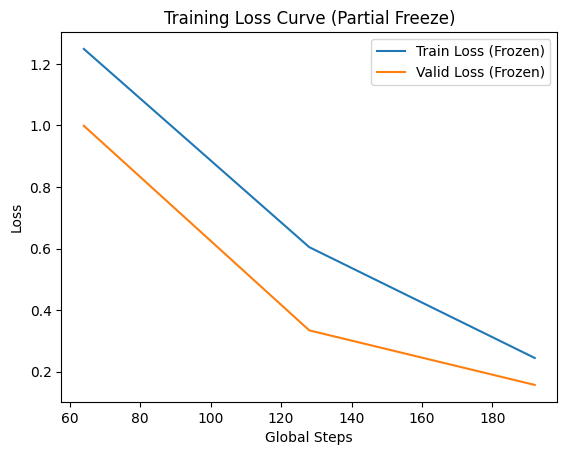

In [68]:
# ======================5-3-2-loss ===============================
train_loss_list, valid_loss_list, global_steps_list = load_metrics(PATH + '/metrics.pt')
plt.plot(global_steps_list, train_loss_list, label='Train Loss (Frozen)')
plt.plot(global_steps_list, valid_loss_list, label='Valid Loss (Frozen)')
plt.xlabel('Global Steps')
plt.ylabel('Loss')
plt.title('Training Loss Curve (Partial Freeze)')
plt.legend()
plt.show()
# ===========================================================================
